# Gemini セグメンテーション物体検出・カウント

Gemini APIに画像内の主要な物体を検出させ、セグメンテーション輪郭を描画してラベル別に数えます。

モデル: gemini-3.6-flash
画像サイズ: 1448 x 1086


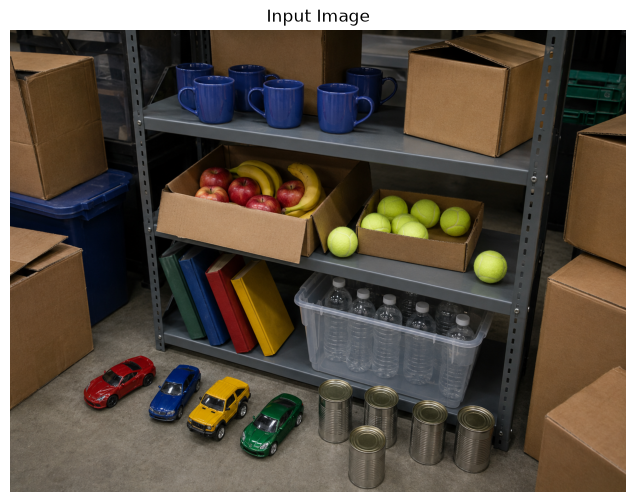

In [1]:
import base64
import mimetypes
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv
from google import genai
from pydantic import BaseModel, Field
from PIL import Image, ImageDraw, ImageFont

load_dotenv(dotenv_path=Path('.env'), override=False)

api_key = os.environ.get('GEMINI_API_KEY')
model_name = os.environ.get('GEMINI_MODEL')
missing = [name for name, value in {'GEMINI_API_KEY': api_key, 'GEMINI_MODEL': model_name}.items() if not value]
if missing:
    raise EnvironmentError('環境変数が未設定です: ' + ', '.join(missing) + '。README.md の API設定 を確認してください。')

image_path = Path('../assets/test1.png')
if not image_path.is_file():
    raise FileNotFoundError(f'入力画像が見つかりません: {image_path.resolve()}')

image = Image.open(image_path).convert('RGB')
client = genai.Client(api_key=api_key)
print(f'モデル: {model_name}')
print(f'画像サイズ: {image.width} x {image.height}')
plt.figure(figsize=(10, 6))
plt.imshow(image)
plt.axis('off')
plt.title('Input Image')
plt.show()

In [2]:
class SegmentationItem(BaseModel):
    label: str = Field(description='A concise English label for one object instance.')
    label_ja: str = Field(default='', description='A concise Japanese label for the same object instance.')
    box_2d: list[float] = Field(description='[ymin, xmin, ymax, xmax] normalized to 0-1000.')
    mask: list[list[float]] = Field(description='Contour polygon as [[x, y], ...], normalized to 0-1000.')


class SegmentationResponse(BaseModel):
    boxes: list[SegmentationItem]


prompt = '''
Return instance segmentation masks for all prominent, separately countable objects in this image.
Return each visible object instance once; do not return background regions, object parts, or duplicate detections.
For every instance, provide a concise English label, a concise Japanese label (label_ja), box_2d as [ymin, xmin, ymax, xmax],
and mask as a contour polygon [[x, y], ...] that traces the visible boundary of that object.
Do not use box_2d as the mask and do not return rectangular masks unless the object itself is rectangular.
All coordinates must be normalized to 0-1000.
'''

mime_type = mimetypes.guess_type(image_path.name)[0] or 'image/png'
image_data = base64.b64encode(image_path.read_bytes()).decode('ascii')

try:
    interaction = client.interactions.create(
        model=model_name,
        input=[
            {'type': 'text', 'text': prompt},
            {'type': 'image', 'data': image_data, 'mime_type': mime_type},
        ],
        response_format={
            'type': 'text',
            'mime_type': 'application/json',
            'schema': SegmentationResponse.model_json_schema(),
        },
        generation_config={'thinking_level': 'minimal'},
    )
    response = SegmentationResponse.model_validate_json(interaction.output_text)
except Exception as error:
    raise RuntimeError('Gemini APIの呼び出し、または構造化応答の検証に失敗しました。APIキー・モデル名・モデルの画像入力対応を確認してください。') from error

print(f'Geminiが返した候補数: {len(response.boxes)}')

Geminiが返した候補数: 42


In [3]:
def normalize_segmentations(items, image_width, image_height):
    valid = []
    for index, item in enumerate(items):
        label = item.label.strip()
        label_ja = item.label_ja.strip() or label
        if not label or len(item.box_2d) != 4 or len(item.mask) < 3:
            print(f'候補 {index} を無視しました: label、box_2d、または mask が不正です。')
            continue
        try:
            ymin, xmin, ymax, xmax = [max(0.0, min(1000.0, float(value))) for value in item.box_2d]
            points = [
                (max(0.0, min(1000.0, float(point[0]))), max(0.0, min(1000.0, float(point[1]))))
                for point in item.mask
                if len(point) == 2
            ]
        except (TypeError, ValueError):
            print(f'候補 {index} を無視しました: 座標値が不正です。')
            continue
        if len(points) < 3:
            print(f'候補 {index} を無視しました: 有効なポリゴン頂点が3点未満です。')
            continue
        ymin, ymax = sorted((ymin, ymax))
        xmin, xmax = sorted((xmin, xmax))
        if xmin == xmax or ymin == ymax:
            print(f'候補 {index} を無視しました: 面積が0の矩形です。')
            continue
        valid.append({
            'label': label,
            'label_ja': label_ja,
            'display_label': f'{label_ja} ({label})' if label_ja != label else label,
            'box_2d_1000': [ymin, xmin, ymax, xmax],
            'x1': round(xmin / 1000 * image_width, 1),
            'y1': round(ymin / 1000 * image_height, 1),
            'x2': round(xmax / 1000 * image_width, 1),
            'y2': round(ymax / 1000 * image_height, 1),
            'polygon': [(round(x / 1000 * image_width, 1), round(y / 1000 * image_height, 1)) for x, y in points],
        })
    return valid


segmentations = normalize_segmentations(response.boxes, image.width, image.height)
print(f'有効なセグメンテーション数: {len(segmentations)}')

有効なセグメンテーション数: 42


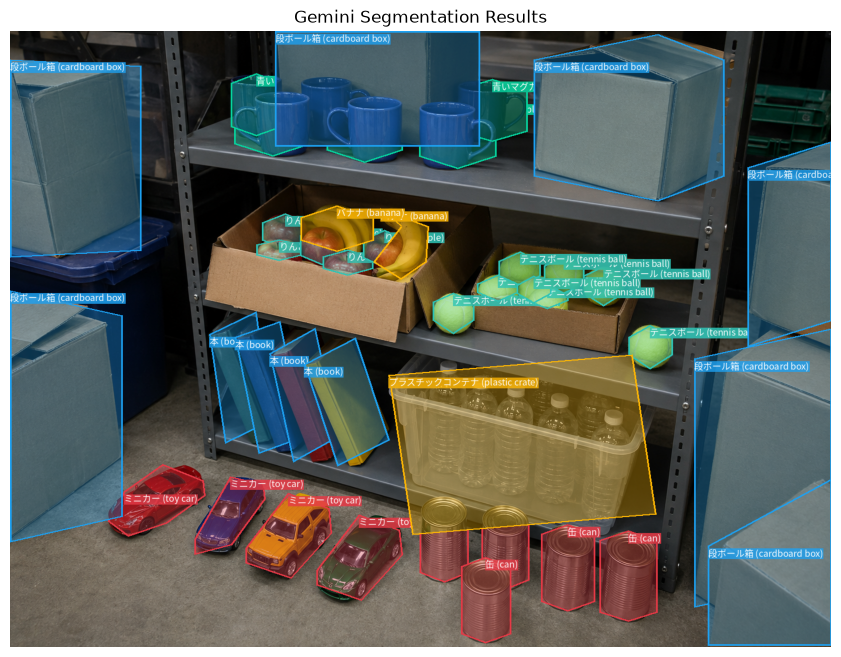

,label_ja,label,box_2d_1000,x1,y1,x2,y2,mask_vertices
0,テニスボール,tennis ball,"[477.0, 752.0, 549.0, 807.0]",1088.9,518.0,1168.5,596.2,6
1,テニスボール,tennis ball,"[382.0, 698.0, 447.0, 748.0]",1010.7,414.9,1083.1,485.4,6
2,テニスボール,tennis ball,"[425.0, 515.0, 492.0, 565.0]",745.7,461.6,818.1,534.3,6
3,テニスボール,tennis ball,"[412.0, 628.0, 452.0, 680.0]",909.3,447.4,984.6,490.9,6
4,テニスボール,tennis ball,"[395.0, 569.0, 440.0, 619.0]",823.9,429.0,896.3,477.8,6
5,テニスボール,tennis ball,"[366.0, 650.0, 427.0, 699.0]",941.2,397.5,1012.2,463.7,6
6,テニスボール,tennis ball,"[358.0, 595.0, 414.0, 646.0]",861.6,388.8,935.4,449.6,6
7,テニスボール,tennis ball,"[397.0, 617.0, 442.0, 659.0]",893.4,431.1,954.2,480.0,6
8,ミニカー,toy car,"[703.0, 119.0, 821.0, 238.0]",172.3,763.5,344.6,891.6,7
9,ミニカー,toy car,"[723.0, 225.0, 850.0, 311.0]",325.8,785.2,450.3,923.1,6


ラベル別の検出数


,label_ja,label,検出数
0,テニスボール,tennis ball,8
1,段ボール箱,cardboard box,7
2,青いマグカップ,blue mug,6
3,りんご,apple,5
4,缶,can,5
5,ミニカー,toy car,4
6,本,book,4
7,バナナ,banana,2
8,プラスチックコンテナ,plastic crate,1


In [4]:
def color_for_label(label):
    palette = [(230, 57, 70), (29, 161, 242), (46, 196, 182), (255, 183, 3), (131, 56, 236), (6, 214, 160)]
    return palette[sum(label.encode('utf-8')) % len(palette)]


overlay = Image.new('RGBA', image.size, (0, 0, 0, 0))
draw = ImageDraw.Draw(overlay)
font_candidates = [
    Path('/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'),
    Path('/usr/share/fonts/truetype/droid/DroidSansFallbackFull.ttf'),
]
font_path = next((path for path in font_candidates if path.is_file()), None)
font = ImageFont.truetype(font_path, size=16) if font_path else ImageFont.load_default()
if font_path is None:
    print('日本語フォントが見つからないため、画像上の日本語ラベルは正しく表示されない場合があります。')

for item in segmentations:
    color = color_for_label(item['label'])
    draw.polygon(item['polygon'], fill=(*color, 80), outline=(*color, 255), width=3)
    x, y = item['polygon'][0]
    text_box = draw.textbbox((x, y), item['display_label'], font=font)
    draw.rectangle(text_box, fill=(*color, 220))
    draw.text((x, y), item['display_label'], fill='white', font=font)

annotated = Image.alpha_composite(image.convert('RGBA'), overlay).convert('RGB')
plt.figure(figsize=(12, 8))
plt.imshow(annotated)
plt.axis('off')
plt.title('Gemini Segmentation Results')
plt.show()

df = pd.DataFrame(segmentations)
if df.empty:
    print('有効な検出結果はありません。')
else:
    display(df[['label_ja', 'label', 'box_2d_1000', 'x1', 'y1', 'x2', 'y2']].assign(mask_vertices=df['polygon'].map(len)))
    counts = df.groupby(['label_ja', 'label']).size().sort_values(ascending=False).rename('検出数').reset_index()
    print('ラベル別の検出数')
    display(counts)